# 第 6 课：奖励黑客

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>访问 <code>requirements.txt</code> 文件：</b> 1) 点击 notebook 顶部菜单中的 <em>"File"</em>，然后 2) 点击 <em>"Open"</em>。

<p> ⬇ &nbsp; <b>下载 Notebook：</b> 1) 点击 notebook 顶部菜单中的 <em>"File"</em>，然后 2) 点击 <em>"Download as"</em> 并选择 <em>"Notebook (.ipynb)"</em>。</p>

<p> 📒 &nbsp; 如需更多帮助，请参阅 <em>"Appendix – Tips, Help, and Download"</em> 课程。</p>

</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>运行结果可能不同：</b> AI 聊天模型生成的输出具有动态性和概率性，因此每次执行的结果都可能不同。如果你的结果和视频中的展示不一致，不必惊讶。</p>

先导入依赖并设置两个客户端，一个用于 OpenAI，另一个用于 Predibase：

In [1]:
import os
from datasets import load_dataset
from dotenv import load_dotenv
from openai import OpenAI

from utils import *

load_dotenv()

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

pb_client = OpenAI(
    base_url=os.environ["PREDIBASE_MODEL_LLAMA_URL"],
    api_key=os.environ["PREDIBASE_API_KEY"],
)

## 用更长的摘要“破解”总结任务

这里你会看到，更长的摘要可能带来更高的奖励。先加载上一课中同样的 earnings call 数据集：

In [2]:
ds = load_dataset("mrSoul7766/ECTSum")
transcript = ds["train"][1]["text"]

基于这通电话内容生成一份测验：

In [3]:
quiz = generate_quiz(transcript)
print(quiz)


Question 1:
What was the adjusted diluted earnings per share for Q1?
A. $4.50
B. $3.34
C. $1.00
D. $2.49

Question 2:
By what percent did comparable store sales grow in Q1?
A. 32.1%
B. 29.4%
C. 24.7%
D. 20.1%

Question 3:
What was the free cash flow for the quarter?
A. $330 million
B. $150 million
C. $200 million
D. $259 million

Question 4:
How much did the company return to shareholders in Q1?
A. $150 million
B. $400 million
C. $203 million
D. $300 million

Question 5:
What was the adjusted operating income for Q1?
A. $113 million
B. $299 million
C. $400 million
D. $500 million

Question 6:
What was the net sales increase for Q1?
A. 20.0%
B. 18.5%
C. 23.4%
D. 25.1%

Question 7:
What was the adjusted gross profit margin for Q1?
A. 44.8%
B. 43.0%
C. 45.0%
D. 42.5%

Question 8:
How much did the company expect to spend on share repurchases in 2021?
A. $100 million to $200 million
B. $300 million to $500 million
C. $200 million to $300 million
D. $500 million to $700 million


生成 8 个通话摘要（这里你仍然会使用在 utils.py 中定义的 Llama-3.1-8B-Instruct-dequantized）：

In [4]:
prompt = f"""Generate a concise bulleted summary of the 
information in the following earnings call transcript.

Only respond with the summary, do not include any extraneous text.

Transcript:

{transcript}
"""

completions = pb_client.chat.completions.create(
    model=MODEL_NAME,
    messages=[
        {"role": "user", "content": prompt},
    ],
    n=8,
    temperature=0.9,
)

让每个摘要去回答这份测验，并得到对应的奖励分数：

In [5]:
responses = [choice.message.content for choice in completions.choices]
quiz_rewards = [quiz_reward(resp, quiz) for resp in responses]
quiz_rewards

[0.5, 0.625, 0.875, 0.5, 0.625, 0.625, 0.75, 0.875]

原始 transcript 应该拿到满分；检查一下是否如此：

In [6]:
transcript_score = quiz_reward(transcript, quiz)
transcript_score

1.0

检查这 8 个摘要的长度，并与完整 transcript 做比较：

In [7]:
lengths = [len(resp) for resp in responses]
lengths

[1362, 1102, 1049, 1342, 1364, 1234, 1218, 1526]

In [8]:
len(transcript)

21810

## 创建一个惩罚函数，抑制更长的摘要

这里你将创建一个奖励函数，对更长的摘要赋予负分（也就是惩罚）。随着训练推进，这个惩罚会抑制模型仅仅通过写得更长来获得更高 quiz 分数的行为。

In [9]:
def length_penalty_reward(response: str) -> float:
    length = len(response)
    target_length = 1024
    if length <= target_length:
        return 0.0
    else:
        return max(
            (target_length - length) / target_length,
            -10
        ) 

In [10]:
transcript_reward = length_penalty_reward(transcript)
transcript_reward

-10

展示这 8 个摘要的长度惩罚及其对应的 advantage：

In [11]:
lengths = [len(resp) for resp in responses]
length_rewards = [
    length_penalty_reward(resp) for resp in responses
]
print_length_table(lengths, length_rewards)

+---------+----------+------------+-------------+
|   Index |   Length |     Reward |   Advantage |
+=========+==========+============+=============+
|       0 |     1362 | -0.330078  |   -0.601312 |
+---------+----------+------------+-------------+
|       1 |     1102 | -0.0761719 |    1.188    |
+---------+----------+------------+-------------+
|       2 |     1049 | -0.0244141 |    1.55274  |
+---------+----------+------------+-------------+
|       3 |     1342 | -0.310547  |   -0.463672 |
+---------+----------+------------+-------------+
|       4 |     1364 | -0.332031  |   -0.615075 |
+---------+----------+------------+-------------+
|       5 |     1234 | -0.205078  |    0.27958  |
+---------+----------+------------+-------------+
|       6 |     1218 | -0.189453  |    0.389691 |
+---------+----------+------------+-------------+
|       7 |     1526 | -0.490234  |   -1.72995  |
+---------+----------+------------+-------------+


把长度惩罚加入 quiz 奖励分数中：

In [12]:
def total_reward(length_reward, quiz_reward):
    return length_reward + quiz_reward

In [13]:
total_rewards = [
    total_reward(length_reward, quiz_reward) 
    for length_reward, quiz_reward
    in zip(length_rewards, quiz_rewards)
]

可视化长度和 quiz 分数之间的权衡，以及它们如何共同决定 advantage：

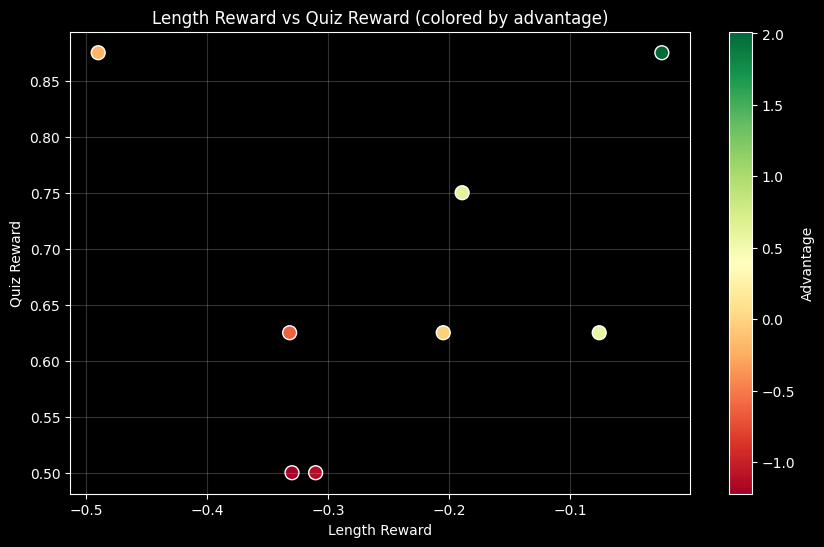

In [14]:
from matplotlib import pyplot as plt

advantages = compute_advantages(total_rewards)
min_adv = min(advantages)
max_adv = max(advantages)

plt.figure(figsize=(10,6), facecolor='black')
plt.style.use('dark_background')
scatter = plt.scatter(length_rewards, quiz_rewards, c=advantages, cmap='RdYlGn', s=100, edgecolor='white', vmin=min_adv, vmax=max_adv)
plt.colorbar(scatter, label='Advantage')
plt.xlabel('Length Reward')
plt.ylabel('Quiz Reward')
plt.title('Length Reward vs Quiz Reward (colored by advantage)')
plt.grid(True, alpha=0.2)
plt.show()